In [1]:
import xarray as xr
import pygmt
import numpy as np
#import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from gplately import Points, PlateReconstruction
#import geopandas as gpd
#from shapely.geometry import Point, LineString
from plate_model_manager import PlateModelManager

# pygmt.config(#FONT="12p,Palatino-Roman", 
#             FONT_ANNOT_PRIMARY="8p,Arial",
#             FONT_ANNOT_SECONDARY="8p,Arial",
#             FONT_LABEL="8p,Arial",
#             IO_SEGMENT_MARKER="<<<",
#             MAP_FRAME_TYPE = 'plain',
#             FORMAT_GEO_MAP = 'D'
#             )

In [59]:
pm_manager = PlateModelManager()
pm_manager.get_available_model_names()

['default',
 'shirmard2025',
 'alfonso2024',
 'cao2024',
 'cao2023',
 'muller2022',
 'zahirovic2022',
 'merdith2021',
 'clennett2020',
 'clennett2020_m2019',
 'clennett2020_s2013',
 'muller2019',
 'young2018',
 'torsvikcocks2017',
 'matthews2016',
 'matthews2016_mantle_ref',
 'matthews2016_pmag_ref',
 'muller2016',
 'scotese2016',
 'zahirovic2016',
 'gibbons2015',
 'domeier2014',
 'zahirovic2014',
 'shephard2013',
 'gurnis2012',
 'seton2012',
 'li2008',
 'muller2008',
 'golonka',
 'paleomap',
 'rodinia']

In [ ]:
# Request Matthews2016 from GPlately
pm_manager = PlateModelManager()

#plate_model_ref = 'matthews2016_mantle_ref'
plate_model_ref = 'muller2019'
plate_model = pm_manager.get_model(plate_model_ref, data_dir="plate-model-repo")
#muller2016_model = pm_manager.get_model("Muller2016", data_dir="plate-model-repo")

rotation_model = plate_model.get_rotation_model()
topology_features = plate_model.get_topologies()
static_polygons = plate_model.get_static_polygons()

coastlines = plate_model.get_layer('Coastlines')

# Call the PlateReconstruction object to create a plate motion model
recon_model_mu = PlateReconstruction(rotation_model, topology_features, static_polygons)
#print(rotation_model)
#rotation_model.get_time_range()

In [186]:
#or shape reconstruction
#hot=np.loadtxt('../../../data/hotspots/hotspots_whittaker2015.xy')
with open('../../../data/hotspots/hotspots_whittaker2015.xy', 'r') as f:
    lines = [line for line in f if not line.lstrip().startswith('>')]
hot_data = np.loadtxt(lines)
lons, lats = hot_data[:, 0], hot_data[:, 1]

# Plate IDs
moving_plate_ID = 1     #Atlantic reference frame
anchor_plate_ID = 201   #South America Plate

# Create the time array for the motion path - must be float
start_reconstruction_time = 0.
time_step = 10.
max_reconstruction_time = 200.
time_array = np.arange(start_reconstruction_time, max_reconstruction_time + time_step, time_step)

# Get the latitudes and longitudes of all points along the motion path
rlons, rlats, rtimes, rates_of_motion = recon_model_mu.create_motion_path(
    lons,
    lats,
    time_array,
    # Specify the reconstruction time...
    #from_time=0,
    #to_time=200,
    plate_id=None,
    anchor_plate_id=201,
    return_times=True,
    return_rate_of_motion=True,
    #remove_unreconstructable_points=True
    )

lons, lats = -40, -25 #test for Tristan
# Get the latitudes and longitudes of all points along the motion path
rlons_tr, rlats_tr, rtimes, rates_of_motion = recon_model_mu.create_motion_path(
    lons,
    lats,
    time_array,
    # Specify the reconstruction time...
    from_time=100,
    #to_time=200,
    plate_id=moving_plate_ID,
    anchor_plate_id=anchor_plate_ID,
    return_times=True,
    return_rate_of_motion=True)

In [187]:
print(rlons)

[[ 167.          165.91886948  167.84145302 ...    1.87836033
     1.87836033    1.87836033]
 [ 163.          161.0569332   160.4803247  ...   32.06279393
    32.06279393   32.06279393]
 [ -61.          -64.02629499  -68.42575171 ...  -63.81770261
   -63.81770261  -63.81770261]
 ...
 [  78.575891     75.73442755   72.6564545  ...   23.90491414
    23.90491414   23.90491414]
 [-151.         -144.92999871 -139.75388299 ... -111.2702292
  -114.33060267 -109.53239201]
 [-136.         -133.01880284 -129.46047059 ... -121.35224083
  -120.83212761 -121.48371802]]


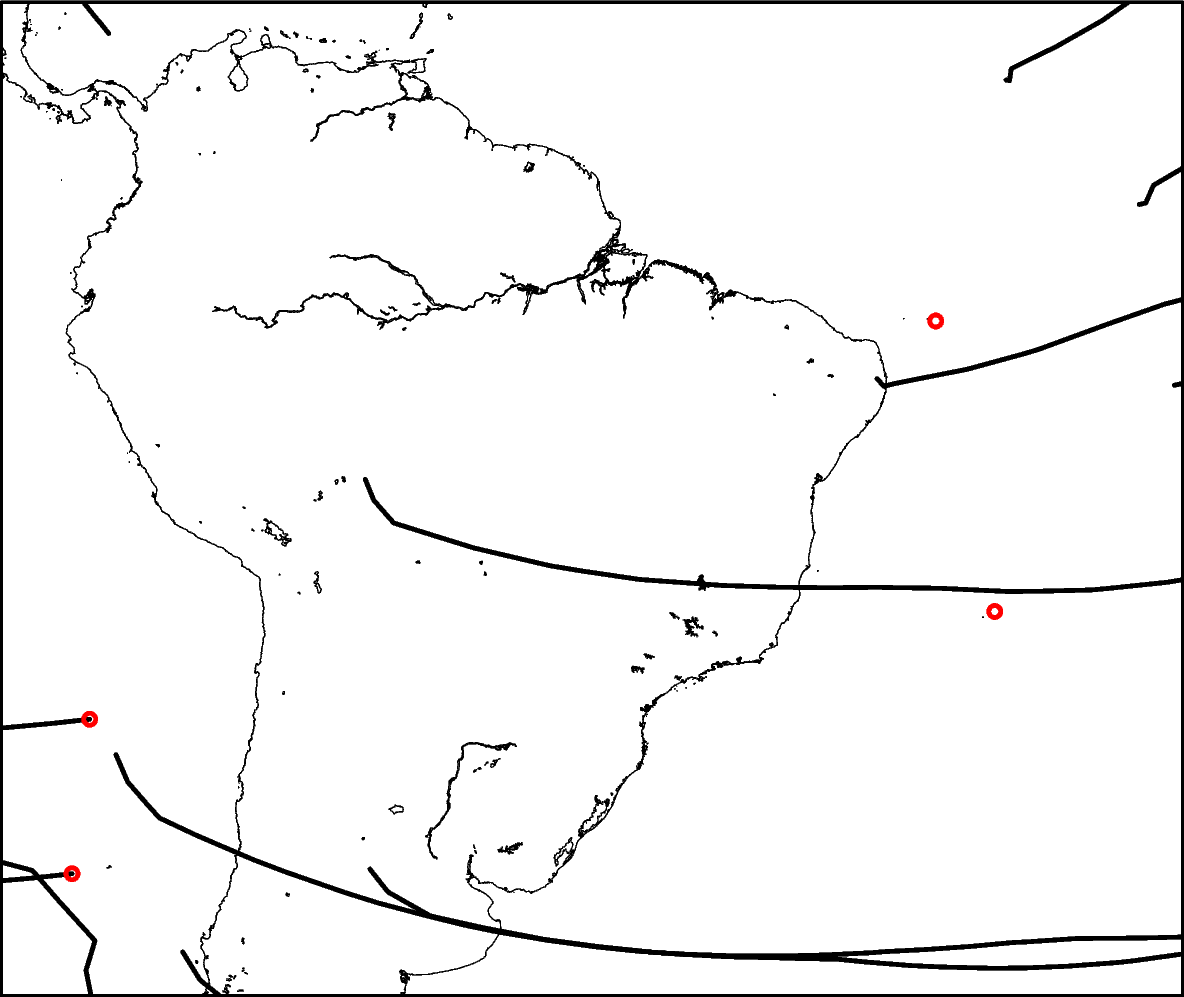

[167.         165.91886948 167.84145302 170.4404881  169.38157596
 165.60549018 158.66094208 151.44368535 139.72157743 121.91591602
 101.40782315  63.28985437  38.91152601  16.37361018   9.09250564
   5.23546904   3.73083114   2.5569266    1.87836033   1.87836033
   1.87836033]


In [188]:
region = [-85,-18,-40,14]  # [west, east, south, north]

fig = pygmt.Figure()
fig.basemap(
    region=region,
    projection="J10",
    frame=["a10", "lrbt"]
)
fig.coast(
    shorelines="0.2p,black",
    #borders="0.5p,black",
    resolution="h"
)
for i in range(rlons.shape[0]):
    fig.plot(x=rlons[i], y=rlats[i], pen="1p")
fig.plot(x=rlons_tr[0], y=rlats_tr[0], pen="1p,blue")
fig.plot(x=rlons[0], y=rlats[0], pen="1p,green", style="c0.1c", label="Start")
fig.plot(x=hot_data[:, 0], y=hot_data[:, 1], style="c0.1c", pen="1p,red", label="Hotspots")
fig.show()
print(rlons[0])